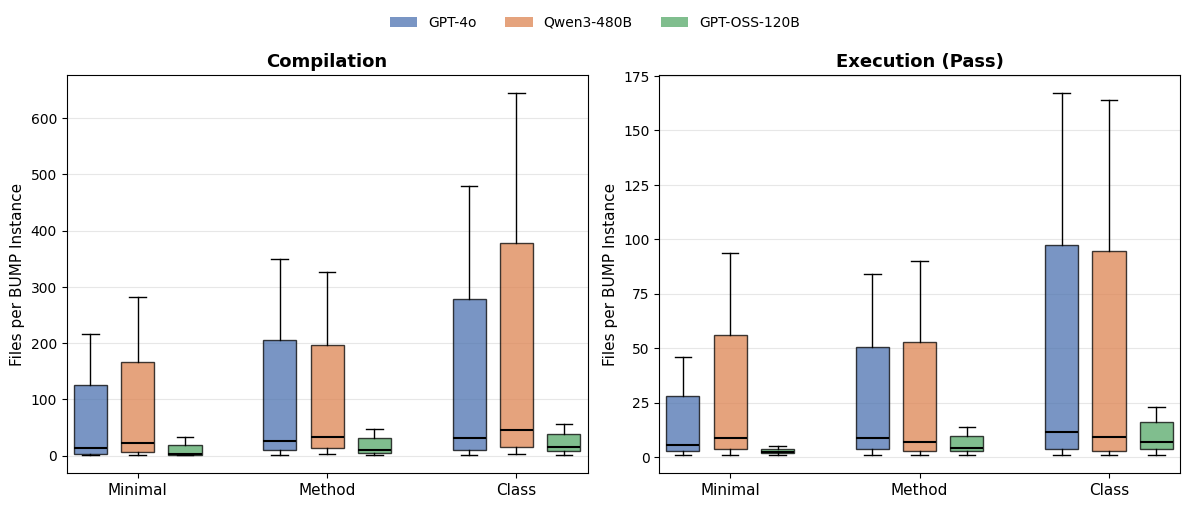

Saved: boxplot_per_instance_stats.pdf / .png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---------------------------------------------------------------------
# DATA: Replace these with your actual per-instance distributions.
# Each entry is a list of file counts per BUMP instance.
# Below are synthetic samples that match the reported median & range.
# ---------------------------------------------------------------------

def synthetic(n_inst, median, lo, hi, size_approx=50):
    """Generate a rough synthetic distribution matching median/range."""
    rng = np.random.default_rng(42)
    left = rng.integers(lo, max(median, lo + 1), size=size_approx // 2)
    right = rng.integers(median, hi + 1, size=size_approx // 2)
    data = np.concatenate([left, right])
    return data

# --- Compilation data (median, min, max) per (context, model) ---
comp_stats = {
    ("Minimal", "GPT-4o"):       (7.0,   1, 222),
    ("Minimal", "Qwen3-480B"):   (14.0,  1, 291),
    ("Minimal", "GPT-OSS-120B"): (3.5,   1, 33),
    ("Method",  "GPT-4o"):       (17.0,  1, 359),
    ("Method",  "Qwen3-480B"):   (25.0,  1, 336),
    ("Method",  "GPT-OSS-120B"): (10.5,  1, 49),
    ("Class",   "GPT-4o"):       (17.0,  1, 492),
    ("Class",   "Qwen3-480B"):   (27.0,  1, 662),
    ("Class",   "GPT-OSS-120B"): (15.5,  1, 57),
}

exec_stats = {
    ("Minimal", "GPT-4o"):       (5.0, 1, 47),
    ("Minimal", "Qwen3-480B"):   (7.0, 1, 96),
    ("Minimal", "GPT-OSS-120B"): (3.0, 1, 5),
    ("Method",  "GPT-4o"):       (7.0, 1, 86),
    ("Method",  "Qwen3-480B"):   (5.5, 1, 92),
    ("Method",  "GPT-OSS-120B"): (5.0, 1, 14),
    ("Class",   "GPT-4o"):       (7.0, 1, 171),
    ("Class",   "Qwen3-480B"):   (5.5, 1, 168),
    ("Class",   "GPT-OSS-120B"): (7.0, 1, 23),
}

# Generate synthetic data (REPLACE with real data for final figure)
comp_data = {k: synthetic(50, *v) for k, v in comp_stats.items()}
exec_data = {k: synthetic(50, *v) for k, v in exec_stats.items()}

# ---------------------------------------------------------------------
# PLOT
# ---------------------------------------------------------------------
contexts = ["Minimal", "Method", "Class"]
models = ["GPT-4o", "Qwen3-480B", "GPT-OSS-120B"]
colors = {"GPT-4o": "#4C72B0", "Qwen3-480B": "#DD8452", "GPT-OSS-120B": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, (data, title) in zip(axes, [(comp_data, "Compilation"), (exec_data, "Execution (Pass)")]):
    positions = []
    box_data = []
    tick_positions = []
    tick_labels = []
    box_colors = []

    for ci, ctx in enumerate(contexts):
        base = ci * 4  # spacing between context groups
        for mi, model in enumerate(models):
            pos = base + mi
            positions.append(pos)
            box_data.append(data[(ctx, model)])
            box_colors.append(colors[model])
        tick_positions.append(base + 1)
        tick_labels.append(ctx)

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=0.7,
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker="o", markersize=3, alpha=0.5),
        medianprops=dict(color="black", linewidth=1.5),
    )

    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Files per BUMP Instance", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

# Legend
handles = [mpatches.Patch(facecolor=colors[m], label=m, alpha=0.75) for m in models]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 1.02), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("boxplot_per_instance_stats.pdf", bbox_inches="tight", dpi=300)
plt.savefig("boxplot_per_instance_stats.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved: boxplot_per_instance_stats.pdf / .png")